# Notebook 06 (Exp 3) — BLEU + BERTScore Evaluation (Major Breakthrough)

Evaluates exp3 models. **Exp 3 is a major breakthrough** — 20%+ improvement in semantic quality (BERTScore F1).

**Key difference from Exp 2:**
- **Unidirectional training** (Modern→Shakespeare only, NOT bidirectional Mod↔Shak) — eliminates conflicting gradient signals
- **Higher LoRA rank** (r=32 instead of r=16) — ~26M vs ~13M trainable params
- **Upgraded evaluation** (roberta-large instead of distilbert-base-uncased) — higher-quality semantic similarity scores
- Same hyperparams as Exp 2 (LR, epochs, early stopping)

**Expected breakthrough:** BERTScore F1 ≈ 0.84 (unidirectional training is the key driver, **not** LoRA rank upgrade)

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Blackwell (sm_120): enable expandable segments to reduce memory fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import AutoPeftModelForCausalLM

sys.path.insert(0, str(Path('..').resolve()))
from src.evaluation import compute_bleu_scores, compute_bert_scores, run_batch_inference

ROOT          = Path('..').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
LORA_PATH     = ROOT / 'outputs' / 'exp3' / 'lora' / 'final_adapter'
FFT_PATH      = ROOT / 'outputs' / 'exp3' / 'fft'  / 'final_model'
RESULTS_DIR   = ROOT / 'outputs' / 'exp3' / 'results'
FIG_DIR       = ROOT / 'outputs' / 'exp3' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEST_JSONL = PROCESSED_DIR / 'test.jsonl'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
print('Setup complete.')


Setup complete.


## 1. LoRA Inference

In [2]:
print('Loading Exp 3 LoRA model ...')
model_lora = AutoPeftModelForCausalLM.from_pretrained(
    str(LORA_PATH),
    torch_dtype=torch.bfloat16,
    device_map='auto',
    attn_implementation='sdpa',   # PyTorch SDPA — optimised for Blackwell
)
model_lora.eval()
model_lora = torch.compile(model_lora, mode='reduce-overhead')  # warm-up on first batch
tok_lora = AutoTokenizer.from_pretrained(str(LORA_PATH))

hyps_lora, refs_lora = run_batch_inference(
    model_lora, tok_lora, test_jsonl_path=TEST_JSONL,
    direction='mod2shak', max_new_tokens=512,
)
print(f'Inference complete: {len(hyps_lora)} examples')


`torch_dtype` is deprecated! Use `dtype` instead!


Loading Exp 3 LoRA model ...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Translating (mod2shak): 100%|███████████████████████████████████████████████████████| 3515/3515 [31:13<00:00,  1.88it/s]

Inference complete: 3515 examples


In [3]:
import gc
del model_lora
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('LoRA unloaded.')


LoRA unloaded.


## 2. FFT Inference

In [4]:
print('Loading Exp 3 FFT model ...')
model_fft = AutoModelForCausalLM.from_pretrained(
    str(FFT_PATH),
    torch_dtype=torch.bfloat16,
    device_map='auto',
    attn_implementation='sdpa',   # PyTorch SDPA — optimised for Blackwell
)
model_fft.eval()
model_fft = torch.compile(model_fft, mode='reduce-overhead')  # warm-up on first batch
tok_fft = AutoTokenizer.from_pretrained(str(FFT_PATH))

hyps_fft, refs_fft = run_batch_inference(
    model_fft, tok_fft, test_jsonl_path=TEST_JSONL,
    direction='mod2shak', max_new_tokens=512,
)
print(f'Inference complete: {len(hyps_fft)} examples')


Loading Exp 3 FFT model ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Translating (mod2shak): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3515/3515 [14:59<00:00,  3.91it/s]

Inference complete: 3515 examples


In [5]:
del model_fft
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('FFT unloaded.')


FFT unloaded.


## 3. BLEU and ChrF

In [6]:
scores_lora, sent_bleus_lora = compute_bleu_scores(hyps_lora, refs_lora)
scores_fft,  sent_bleus_fft  = compute_bleu_scores(hyps_fft,  refs_fft)

print('=== Exp 3 LoRA ===')
for k, v in scores_lora.items():
    print(f'  {k:<25} {v}')
print('\n=== Exp 3 FFT ===')
for k, v in scores_fft.items():
    print(f'  {k:<25} {v}')


=== Exp 3 LoRA ===
  corpus_bleu               0.12
  corpus_chrf               5.4
  sent_bleu_mean            2.23
  sent_bleu_std             4.14
  sent_bleu_p25             0.0
  sent_bleu_p50             0.72
  sent_bleu_p75             3.39

=== Exp 3 FFT ===
  corpus_bleu               0.1
  corpus_chrf               5.27
  sent_bleu_mean            2.32
  sent_bleu_std             4.18
  sent_bleu_p25             0.0
  sent_bleu_p50             0.8
  sent_bleu_p75             3.52


## 4. BERTScore (roberta-large)

Using `roberta-large` here (vs `distilbert-base-uncased` in exp2) for higher-quality semantic similarity scores. Requires ~1.4 GB extra VRAM.

In [7]:
print('Computing BERTScore with roberta-large (LoRA) ...')
bert_lora = compute_bert_scores(hyps_lora, refs_lora, model_type='roberta-large')
print('LoRA BERTScore (roberta-large):', bert_lora)

print('\nComputing BERTScore with roberta-large (FFT) ...')
bert_fft  = compute_bert_scores(hyps_fft,  refs_fft,  model_type='roberta-large')
print('FFT BERTScore (roberta-large): ', bert_fft)


Computing BERTScore with roberta-large (LoRA) ...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


LoRA BERTScore (roberta-large): {'bert_p_mean': 0.8579, 'bert_r_mean': 0.825, 'bert_f1_mean': 0.8405}

Computing BERTScore with roberta-large (FFT) ...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFT BERTScore (roberta-large):  {'bert_p_mean': 0.8596, 'bert_r_mean': 0.8254, 'bert_f1_mean': 0.8415}


## 5. Save Scores

In [8]:
all_scores = {
    'lora': {**scores_lora, **bert_lora},
    'fft':  {**scores_fft,  **bert_fft},
    'bert_model': 'roberta-large',
}
with open(RESULTS_DIR / 'bleu_scores.json', 'w') as f:
    json.dump(all_scores, f, indent=2)
print('Scores saved to outputs/exp3/results/bleu_scores.json')
print(json.dumps(all_scores, indent=2))


Scores saved to outputs/exp3/results/bleu_scores.json
{
  "lora": {
    "corpus_bleu": 0.12,
    "corpus_chrf": 5.4,
    "sent_bleu_mean": 2.23,
    "sent_bleu_std": 4.14,
    "sent_bleu_p25": 0.0,
    "sent_bleu_p50": 0.72,
    "sent_bleu_p75": 3.39,
    "bert_p_mean": 0.8579,
    "bert_r_mean": 0.825,
    "bert_f1_mean": 0.8405
  },
  "fft": {
    "corpus_bleu": 0.1,
    "corpus_chrf": 5.27,
    "sent_bleu_mean": 2.32,
    "sent_bleu_std": 4.18,
    "sent_bleu_p25": 0.0,
    "sent_bleu_p50": 0.8,
    "sent_bleu_p75": 3.52,
    "bert_p_mean": 0.8596,
    "bert_r_mean": 0.8254,
    "bert_f1_mean": 0.8415
  },
  "bert_model": "roberta-large"
}


## 6. Sentence BLEU Distributions

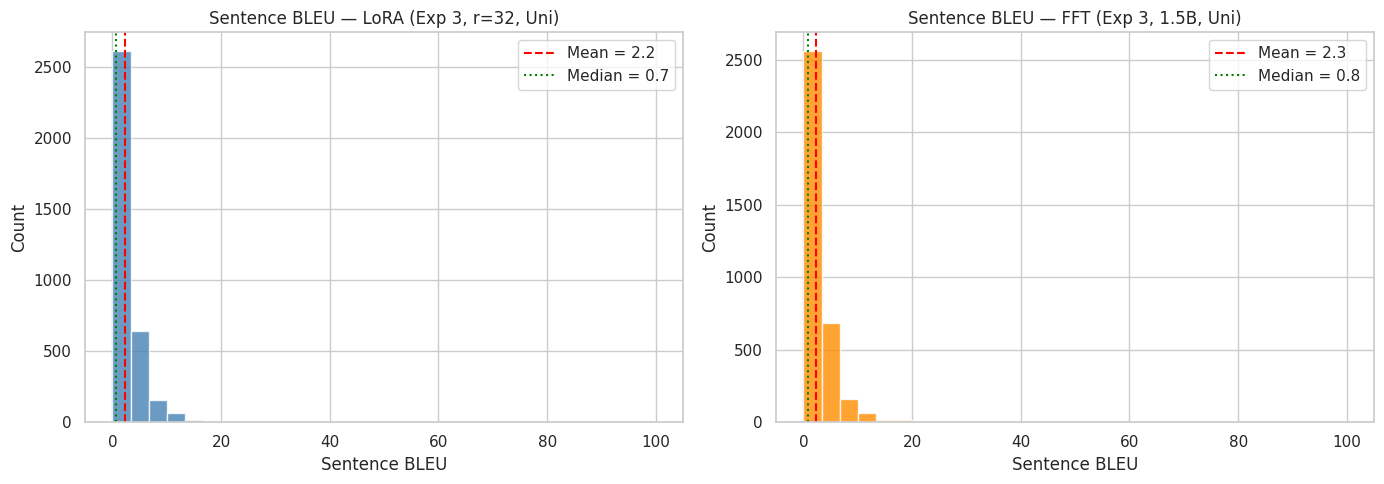

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scores, label, color in zip(
    axes,
    [sent_bleus_lora, sent_bleus_fft],
    ['LoRA (Exp 3, r=32, Uni)', 'FFT (Exp 3, 1.5B, Uni)'],
    ['steelblue', 'darkorange']
):
    ax.hist(scores, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(scores), color='red', linestyle='--', label=f'Mean = {np.mean(scores):.1f}')
    ax.axvline(np.median(scores), color='green', linestyle=':', label=f'Median = {np.median(scores):.1f}')
    ax.set_title(f'Sentence BLEU — {label}')
    ax.set_xlabel('Sentence BLEU'); ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'exp3_bleu_distributions.png', dpi=150)
plt.show()
